<a href="https://colab.research.google.com/github/tohmy-hub/my-python-projects/blob/main/web_scraping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as st

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score

In [ ]:
df = pd.read_csv('/content/nigeria_houses_data.csv')

In [ ]:
df.iloc[0,2]

np.float64(5.0)

In [ ]:
df.columns

Index(['bedrooms', 'bathrooms', 'toilets', 'parking_space', 'title', 'town',
       'state', 'price'],
      dtype='object')

In [ ]:
encoder = LabelEncoder()
df["title"] = encoder.fit_transform(df["title"])
df["town"] = encoder.fit_transform(df["town"])
df["state"] = encoder.fit_transform(df["state"])

In [ ]:
df.head()

,bedrooms,bathrooms,toilets,parking_space,title,town,state,price
0,6.0,5.0,5.0,4.0,2,127,1,450000000.0
1,4.0,5.0,5.0,4.0,6,110,1,800000000.0
2,4.0,5.0,5.0,4.0,2,122,17,120000000.0
3,4.0,4.0,5.0,6.0,2,10,17,40000000.0
4,4.0,4.0,5.0,2.0,4,122,17,75000000.0


In [ ]:
X = df[['bedrooms','bathrooms', 'toilets','parking_space','title','town','state']]
Y = df['price']

model = LinearRegression().fit(X,Y)

In [ ]:
Ypred = model.predict(X)

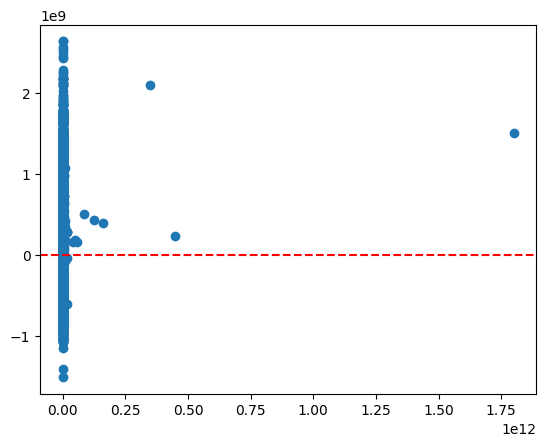

In [ ]:
plt.scatter(Y,Ypred)
plt.axhline(y=0,color='red',linestyle="--")

In [ ]:
res = Y - Ypred

In [ ]:
X = sm.add_constant(X)
model2 = sm.OLS(Y,X).fit()

In [ ]:
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     3.294
Date:                Tue, 07 Apr 2026   Prob (F-statistic):            0.00167
Time:                        11:33:55   Log-Likelihood:            -5.9948e+05
No. Observations:               24326   AIC:                         1.199e+06
Df Residuals:                   24318   BIC:                         1.199e+06
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -1.263e+09    4.9e+08     -2.579      0.010   -2.22e+09   -3.03e+08
bedrooms       2.298e+08   1.02e+08      2.255      0.024       3e+07     4.3e+08
bathrooms      1.021e+08   1.14e+08      0.897      0.370   -1.21e+08    3.25e+08
toilets       -7.543e+07    9.5e+07     -0.794      0.427   -2.62e+08    1.11e+08
parking_space  1.335e+08   5.81e+07      2.299      0.022    1.97e+07    2.47e+08
title          1.334e+07   4.91e+07      0.272      0.786   -8.29e+07     1.1e+08
town           -1.56e+06   1.78e+06     -0.874      0.382   -5.06e+06    1.94e+06
state           4.85e+06   1.32e+07      0.367      0.714   -2.11e+07    3.08e+07
==============================================================================
Omnibus:                   106039.878   Durbin-Watson:                   2.000
Prob(Omnibus):                  0.000   Jarque-Bera (JB):     386642325125.010
Skew:                         134.935   Prob(JB):                         0.00
Kurtosis:                   19532.157   Cond. No.                         698.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
Ypred2 = model2.predict(X)

ASSUMPTION OF LINEARITY OF LINEAR REGRESSION


In [ ]:
res = model2.resid

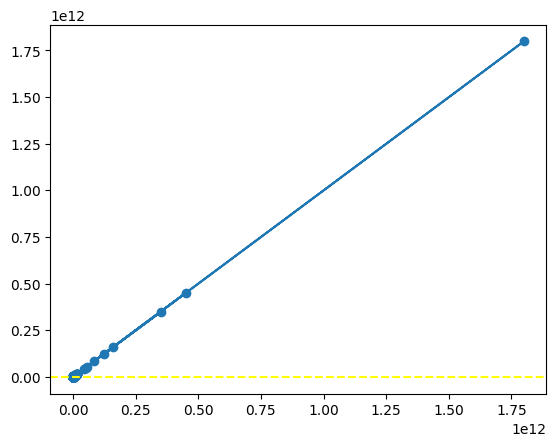

In [ ]:
plt.scatter(Y,res)
plt.plot(Y,res)
plt.axhline(y=0,color='yellow',linestyle="--")

ASSUMPTION OF NORMALITY OF LINEAR REGRESSION

(array([2.4323e+04, 1.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([-2.47495800e+09,  1.77621770e+11,  3.57718498e+11,  5.37815225e+11,
         7.17911953e+11,  8.98008681e+11,  1.07810541e+12,  1.25820214e+12,
         1.43829886e+12,  1.61839559e+12,  1.79849232e+12]),
 <BarContainer object of 10 artists>)

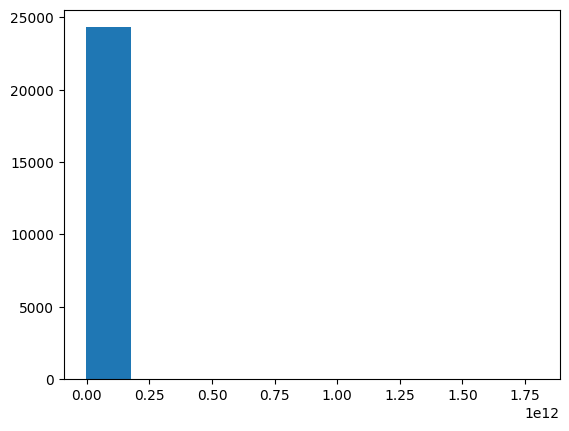

In [ ]:
plt.hist(res)

<Axes: ylabel='Count'>

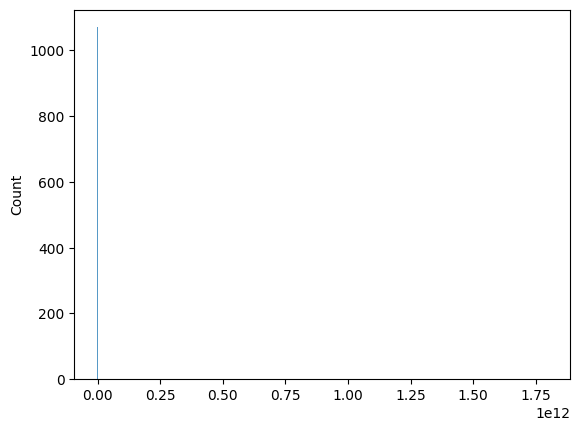

In [ ]:
sns.histplot(res)

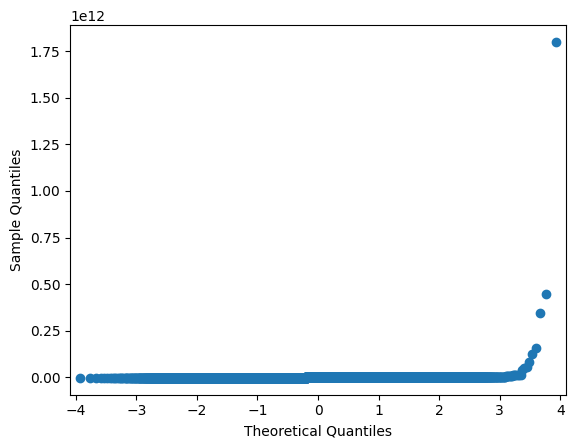

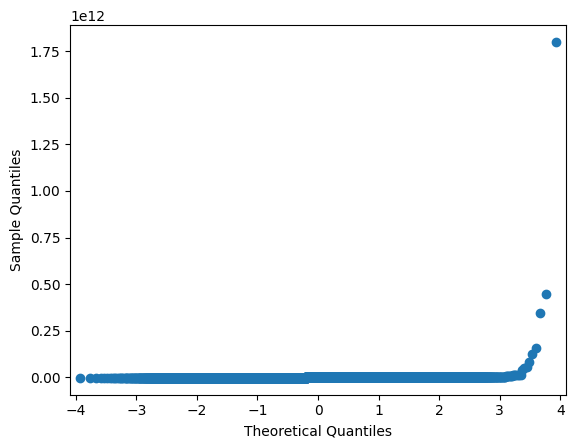

In [ ]:
sm.qqplot(res)